# Выполнил
Трифонов Дмитрий Сергеевич, 12-25РПм, 1 курс, Программная инженерия

# Практическое занятие 3.1 — Основы TensorFlow и работа с тензорами

## Цели работы
1. Освоить базовые понятия TensorFlow: тензор, форма, тип данных, ранг.
2. Научиться создавать и изменять тензоры, выполнять математические операции.
3. Изучить принцип автоматического дифференцирования (tf.GradientTape).
4. Освоить реализацию градиентного спуска и исследовать влияние шага обучения.

In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.3.5


## 1. Пример: скаляр, вектор, матрица

In [23]:
a = tf.constant(5)
b = tf.constant([1, 2, 3])
c = tf.constant([[1.0, 2.0],[3.0, 4.0]])
for name, t in zip(['a','b','c'], [a,b,c]):
    print(f'{name}: rank={tf.rank(t).numpy()}, shape={t.shape}, dtype={t.dtype}')

a: rank=0, shape=(), dtype=<dtype: 'int32'>
b: rank=1, shape=(3,), dtype=<dtype: 'int32'>
c: rank=2, shape=(2, 2), dtype=<dtype: 'float32'>


## 2. Создание тензоров и базовые операции

In [24]:
a = tf.constant([[1, 2], [3, 4]], dtype=tf.float32)
z = tf.zeros((2,3))
o = tf.ones((2,3))
r = tf.random.normal((2,3), mean=0.0, stddev=1.0)
print('a:', a.numpy())
print('zeros:', z.numpy())
print('ones:', o.numpy())
print('random normal:', r.numpy())

a: [[1. 2.]
 [3. 4.]]
zeros: [[0. 0. 0.]
 [0. 0. 0.]]
ones: [[1. 1. 1.]
 [1. 1. 1.]]
random normal: [[ 0.9423027   0.48320058  1.4511673 ]
 [-0.9496124   1.6459464  -0.05953381]]


In [25]:
x = tf.constant([[1,2],[3,4]], dtype=tf.float32)
y = tf.constant([[5,6],[7,8]], dtype=tf.float32)
add = tf.add(x, y)
mul = tf.multiply(x, y)
dot = tf.matmul(x, y)
print('Сумма:', add.numpy())
print('Поэлементное умножение:', mul.numpy())
print('Матричное произведение:', dot.numpy())

Сумма: [[ 6.  8.]
 [10. 12.]]
Поэлементное умножение: [[ 5. 12.]
 [21. 32.]]
Матричное произведение: [[19. 22.]
 [43. 50.]]


## 3. Переменные и GradientTape

In [26]:
x = tf.Variable(3.0)
with tf.GradientTape() as tape:
    y = x**2 + 2*x + 1
dy_dx = tape.gradient(y, x)
print('x =', x.numpy(), ' dy/dx =', dy_dx.numpy())

x = 3.0  dy/dx = 8.0


## 4. Градиентный спуск

step=00, w=0.6000, loss=9.000000
step=05, w=2.2136, loss=0.966368
step=10, w=2.7423, loss=0.103763
step=15, w=2.9156, loss=0.011141
step=20, w=2.9723, loss=0.001196
step=25, w=2.9909, loss=0.000128
Final w: 2.9962862


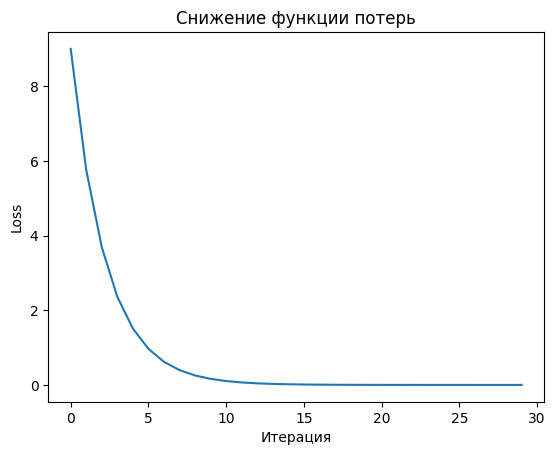

In [27]:
w = tf.Variable(0.0)
alpha = 0.1
history = []
for step in range(30):
    with tf.GradientTape() as tape:
        loss = tf.square(w - 3.0)
    grad = tape.gradient(loss, w)
    w.assign_sub(alpha * grad)
    history.append(float(loss))
    if step % 5 == 0:
        print(f'step={step:02d}, w={w.numpy():.4f}, loss={float(loss):.6f}')
print('Final w:', w.numpy())
plt.plot(history)
plt.title('Снижение функции потерь')
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.show()

## 5. Влияние шага обучения

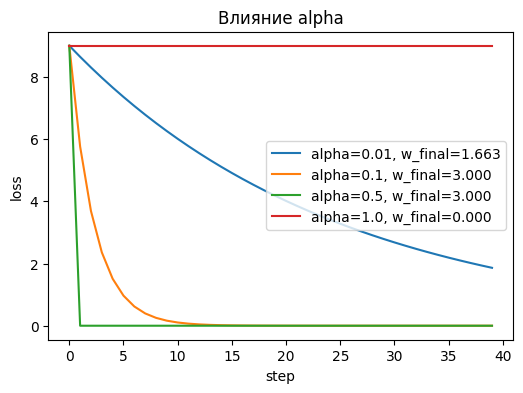

In [28]:
def run_gd(alpha=0.1, steps=30):
    w = tf.Variable(0.0)
    hist = []
    for _ in range(steps):
        with tf.GradientTape() as tape:
            loss = tf.square(w - 3.0)
        grad = tape.gradient(loss, w)
        w.assign_sub(alpha * grad)
        hist.append(float(loss))
    return w.numpy(), hist

plt.figure(figsize=(6,4))
for a in [0.01, 0.1, 0.5, 1.0]:
    w_final, h = run_gd(alpha=a, steps=40)
    plt.plot(h, label=f'alpha={a}, w_final={w_final:.3f}')
plt.legend()
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Влияние alpha')
plt.show()

## 6. Ручной градиентный спуск

In [29]:
w = 0.0
alpha = 0.1
for step in range(10):
    grad = 2*(w - 3.0)
    w = w - alpha * grad
    print(f'step={step:02d}, w={w:.4f}, loss={(w-3.0)**2:.6f}')
print('Final w:', w)

step=00, w=0.6000, loss=5.760000
step=01, w=1.0800, loss=3.686400
step=02, w=1.4640, loss=2.359296
step=03, w=1.7712, loss=1.509949
step=04, w=2.0170, loss=0.966368
step=05, w=2.2136, loss=0.618475
step=06, w=2.3709, loss=0.395824
step=07, w=2.4967, loss=0.253327
step=08, w=2.5973, loss=0.162130
step=09, w=2.6779, loss=0.103763
Final w: 2.6778774528


## 7. Выводы и исследовательская задача

### Выводы по практической работе
1. TensorFlow предоставляет удобный инструмент для работы с тензорами различных рангов и типов.
2. GradientTape позволяет автоматически вычислять производные и упрощает реализацию оптимизационных алгоритмов.
3. Градиентный спуск эффективно находит минимум функции, но скорость и устойчивость зависят от выбора шага обучения.
4. Сравнение автоматического и ручного градиента подтверждает корректность auto-diff.
5. Эксперименты с разными значениями alpha демонстрируют необходимость подбора оптимального шага для сходимости.

## 8. Сравнение с ручным градиентом

In [30]:
w = 0.0
alpha = 0.1
for step in range(10):
    grad = 2*(w - 3.0)
    w -= alpha * grad
    print(f'step={step}, w={w:.4f}, loss={(w-3)**2:.6f}')
print('Вывод: Результаты совпадают с автоматическим градиентом. Auto-diff освобождает от необходимости ручных выводов для сложных сетей.')

step=0, w=0.6000, loss=5.760000
step=1, w=1.0800, loss=3.686400
step=2, w=1.4640, loss=2.359296
step=3, w=1.7712, loss=1.509949
step=4, w=2.0170, loss=0.966368
step=5, w=2.2136, loss=0.618475
step=6, w=2.3709, loss=0.395824
step=7, w=2.4967, loss=0.253327
step=8, w=2.5973, loss=0.162130
step=9, w=2.6779, loss=0.103763
Вывод: Результаты совпадают с автоматическим градиентом. Auto-diff освобождает от необходимости ручных выводов для сложных сетей.


## 9. Исследовательская задача для отчёта
Реализуйте функцию train(alpha, steps), проведите эксперименты с разными alpha и количеством итераций, постройте графики на одной оси и сделайте 3–5 тезисов по результатам.

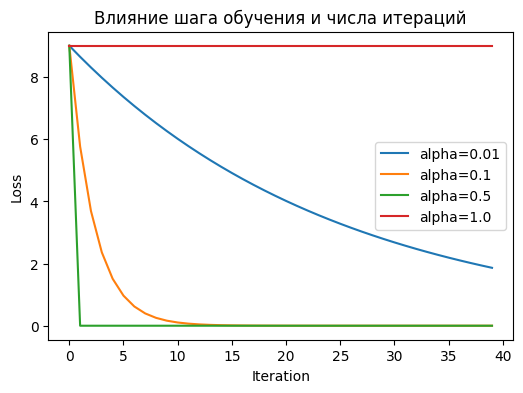

In [31]:
# Функция градиентного спуска с автоматическим дифференцированием
def train(alpha, steps):
    w = tf.Variable(0.0)
    history = []
    for _ in range(steps):
        with tf.GradientTape() as tape:
            loss = tf.square(w - 3.0)
        grad = tape.gradient(loss, w)
        w.assign_sub(alpha * grad)
        history.append(float(loss))
    return history

# Проведение экспериментов с разными alpha и количеством итераций
plt.figure(figsize=(6,4))
for a in [0.01, 0.1, 0.5, 1.0]:
    h = train(a, 40)
    plt.plot(h, label=f'alpha={a}')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Влияние шага обучения и числа итераций')
plt.show()

# Тезисы по результатам эксперимента:
1) Малые alpha (например, 0.01) приводят к медленной сходимости.
2) Оптимальный шаг обучения (0.1) обеспечивает быструю и стабильную сходимость.
3) Слишком большие alpha (0.5, 1.0) вызывают колебания и возможную расходимость.
4) Увеличение числа итераций позволяет достичь минимума при малых alpha.
5) Выбор alpha критически влияет на эффективность и устойчивость градиентного спуска.